# **OI BRO! YA LIKE SOM MAKHIN LERNIG?**




## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Y-Data Profiling

In [4]:
df = pd.read_csv('../data/data.csv', encoding='latin1')
display(df.head())

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,02-03-18 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
try:
    from ydata_profiling import ProfileReport
except ImportError:
    %pip install ydata-profiling
    from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Olist E-commerce Data Profiling Report")
profile.to_file("olist_ecommerce_profile_report.html")
print("Profile report saved to olist_ecommerce_profile_report.html")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 5.4 MB/s eta 0:00:00


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 53/53 [00:20<00:00,  2.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profile report saved to olist_ecommerce_profile_report.html


### Analysis of Correlation: Type vs. Order Status

The high correlation between **Type** (Payment Method) and **Order Status** in this dataset is typically due to the following business rules:

1. **Payment Verification Time**:
   - **TRANSFER**: Often correlates with `PENDING` or `ON_HOLD` statuses because the system waits for bank confirmation.
   - **CASH / DEBIT**: These are often processed immediately, leading more quickly to `CLOSED` or `COMPLETE` statuses.

2. **Transaction Logic**:
   - In supply chain datasets like DataCo, certain order statuses (like `SUSPECTED_FRAUD`) are more frequently triggered by specific payment types (like `TRANSFER` or `PAYMENT`) depending on the security protocols in place.

3. **Data Logging**:
   - Sometimes, specific payment gateways only log certain status transitions, creating a statistical dependency between the two fields.

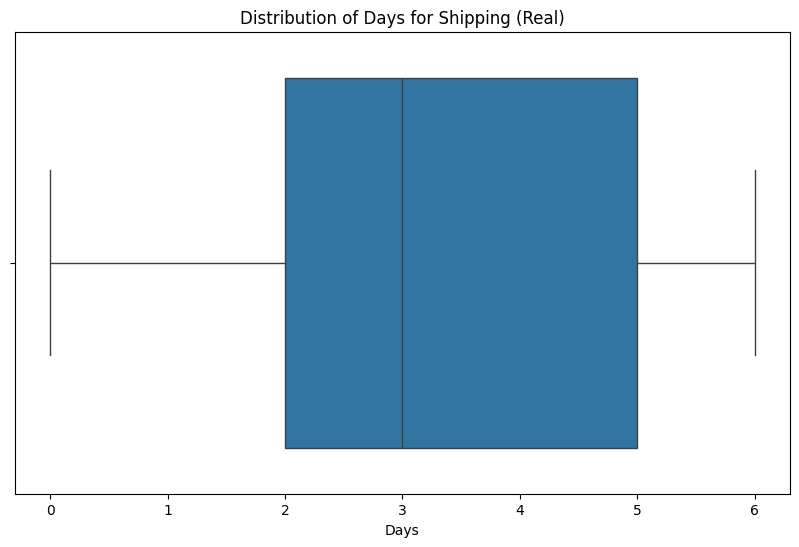

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Days for shipping (real)'])
plt.title('Distribution of Days for Shipping (Real)')
plt.xlabel('Days')
plt.show()

Days for shipping (Scheduled) ==> Real Number (Not Categorical).

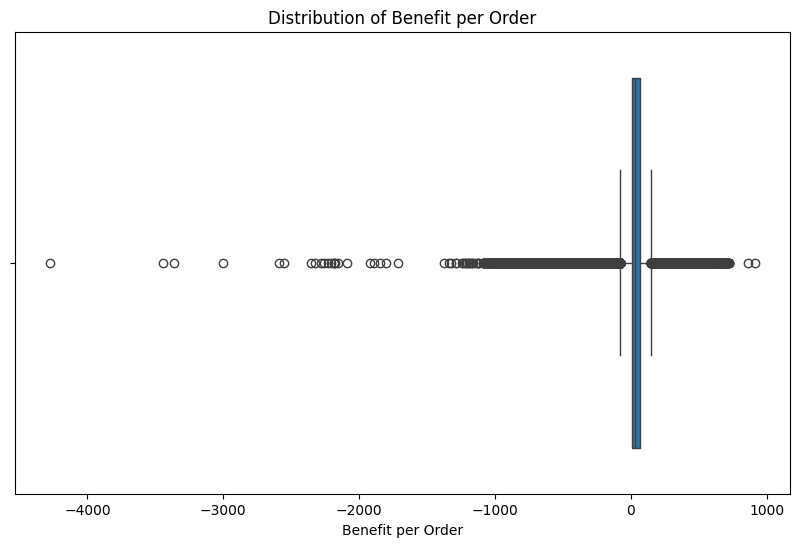

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Benefit per order'])
plt.title('Distribution of Benefit per Order')
plt.xlabel('Benefit per Order')
plt.show()

Benefit per order ==> Requires proper (intensive) preprocessing and analysis.

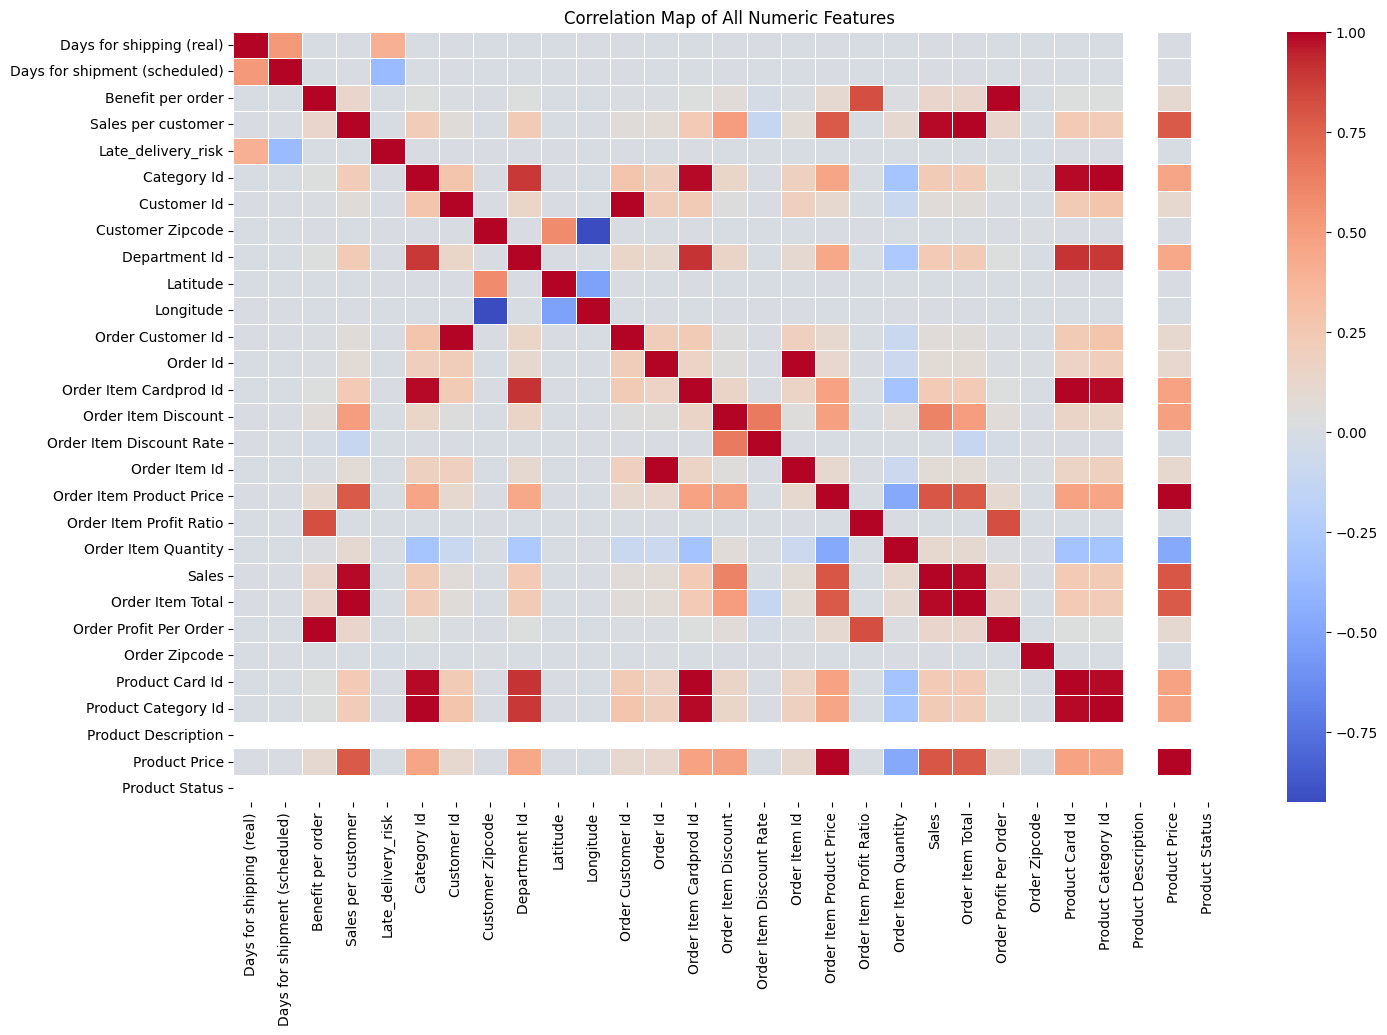

In [9]:
plt.figure(figsize=(16, 10))
# Selecting only numeric columns for correlation
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Map of All Numeric Features')
plt.show()

Sales per person has 1.00 correlation with Sales and Order Item Total.

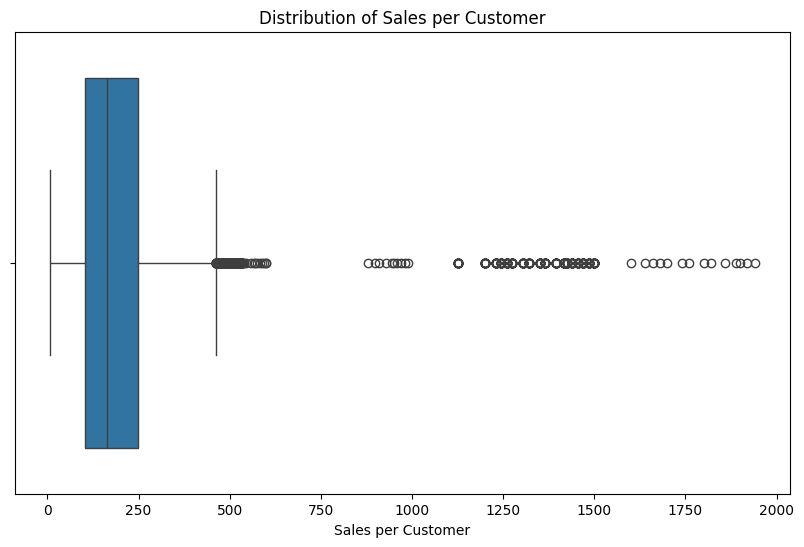

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Sales per customer'])
plt.title('Distribution of Sales per Customer')
plt.xlabel('Sales per Customer')
plt.show()

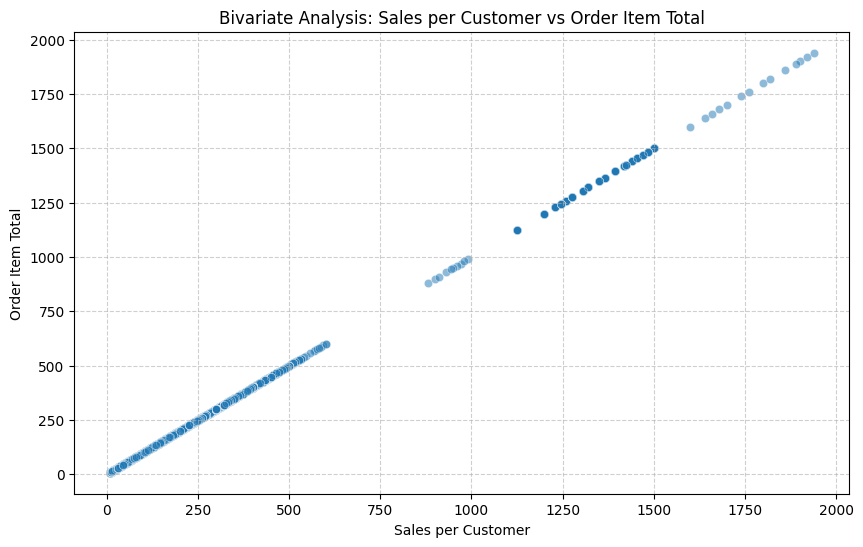

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales per customer', y='Order Item Total', alpha=0.5)
plt.title('Bivariate Analysis: Sales per Customer vs Order Item Total')
plt.xlabel('Sales per Customer')
plt.ylabel('Order Item Total')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Some prices are related (highly correlated) to a special category? (Find out)

Outliers could not mean bad data.

We reached Delivery Status column, and we are now discussing the canceled status and trying to understand it well in these concepts:
- What does the negative benefits mean?
- Continue reading the Gemini response.
- When to ZERO (0) the canceled/fraud benefits?

Above Analysis done.

In [11]:
duplicates = df[df.duplicated(subset=['Order Customer Id'], keep=False)]
print(f"Number of duplicate rows based on Order Customer Id: {len(duplicates)}")
pd.set_option('display.max_columns', None)
display(duplicates.sort_values(by='Order Customer Id').head(1000))

Number of duplicate rows based on Order Customer Id: 172084


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
115207,DEBIT,4,4,3.520000,351.980011,Shipping on time,0,45,Fishing,Littleton,EE. UU.,XXXXXXXXX,Mary,2,Barrett,XXXXXXXXX,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,Europe,Rome,Italia,2,9/17/2017 15:04,67863,1004,48.000000,0.12,169674,399.980011,0.01,1,399.980011,351.980011,3.520000,Southern Europe,Lacio,COMPLETE,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,9/21/2017 15:04,Standard Class
127849,DEBIT,4,4,40.340000,98.379997,Shipping on time,0,17,Cleats,Littleton,EE. UU.,XXXXXXXXX,Mary,2,Barrett,XXXXXXXXX,Consumer,CO,9526 Noble Embers Ridge,80126.0,4,Apparel,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,4/26/2017 2:40,57963,365,21.600000,0.18,145019,59.990002,0.41,2,119.980003,98.379997,40.340000,Central America,Cortés,ON_HOLD,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,4/30/2017 2:40,Standard Class
94974,DEBIT,6,4,10.000000,40.000000,Late delivery,1,24,Women's Apparel,Littleton,EE. UU.,XXXXXXXXX,Mary,2,Barrett,XXXXXXXXX,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,05-09-16 08:04,33865,502,10.000000,0.20,84538,50.000000,0.25,1,50.000000,40.000000,10.000000,East of USA,Nueva York,COMPLETE,10011.0,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,5/15/2016 8:04,Standard Class
95017,DEBIT,6,4,105.629997,290.980011,Late delivery,1,43,Camping & Hiking,Littleton,EE. UU.,XXXXXXXXX,Mary,2,Barrett,XXXXXXXXX,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,05-09-16 08:04,33865,957,9.000000,0.03,84536,299.980011,0.36,1,299.980011,290.980011,105.629997,East of USA,Nueva York,COMPLETE,10011.0,957,43,NaN,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.980011,0,5/15/2016 8:04,Standard Class
144126,PAYMENT,3,4,-131.699997,84.970001,Advance shipping,0,46,Indoor/Outdoor Games,Littleton,EE. UU.,XXXXXXXXX,Mary,2,Barrett,XXXXXXXXX,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,Europe,Munich,Alemania,2,08-10-15 18:05,15192,1014,14.990000,0.15,38007,49.980000,-1.55,2,99.959999,84.970001,-131.699997,Western Europe,Bavaria,PENDING_PAYMENT,NaN,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.980000,0,8/13/2015 18:05,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180411,TRANSFER,2,4,28.500000,379.980011,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,73,Smith,XXXXXXXXX,Home Office,PR,8247 Little Cider Close,725.0,7,Fan Shop,18.227589,-66.043579,Pacific Asia,Geelong,Australia,73,1/22/2016 6:07,26461,1004,20.000000,0.05,66248,399.980011,0.08,1,399.980011,379.980011,28.500000,Oceania,Victoria,PENDING,NaN,1004,45,NaN,http:/